In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data_pipeline import load_data, clean_data, get_feature_columns, build_preprocessing_pipeline

sns.set_style("whitegrid")

df = load_data("../data/raw/Telco_Customer_Churn.xlsx")
df.shape

(7043, 33)

In [2]:
df = clean_data(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

In [3]:
numeric_cols, categorical_cols = get_feature_columns(df, target_col="Churn")
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Tenure Months', 'Monthly Charges', 'Total Charges']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


## Exploratory Data Analysis

In [4]:


churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 26.54%


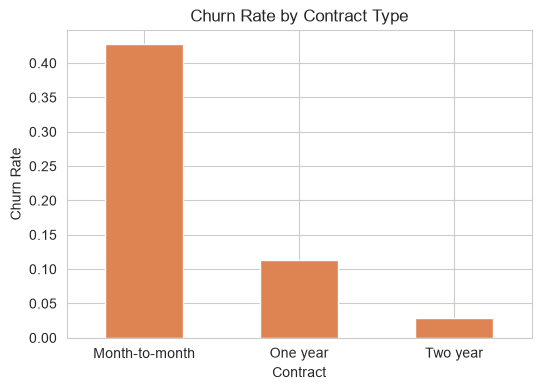

In [5]:
churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
churn_by_contract.plot(kind="bar", figsize=(6,4), color="#DD8452")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

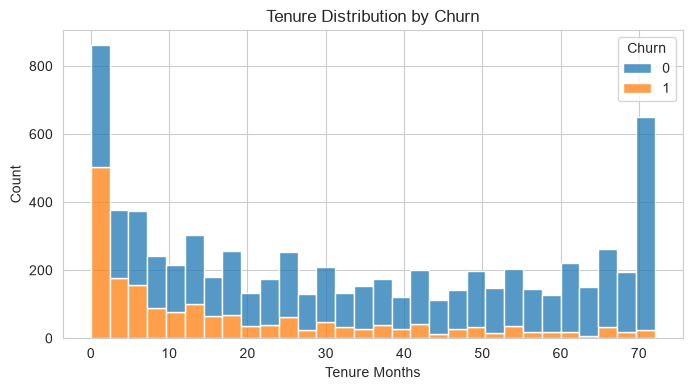

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="Tenure Months", hue="Churn", bins=30, multiple="stack")
plt.title("Tenure Distribution by Churn")
plt.show()

## Feature Engineering & Preprocessing

In [7]:


from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}")

Train shape: (5634, 19), Test shape: (1409, 19)
Train churn rate: 26.54%, Test churn rate: 26.54%


## Model Training

In [8]:


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

preprocessor = build_preprocessing_pipeline(numeric_cols, categorical_cols)

log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Gender','Senior Citizen','Partner',...,'Payment Method', 'Monthly Charges','Total Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

## Evaluation


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8489


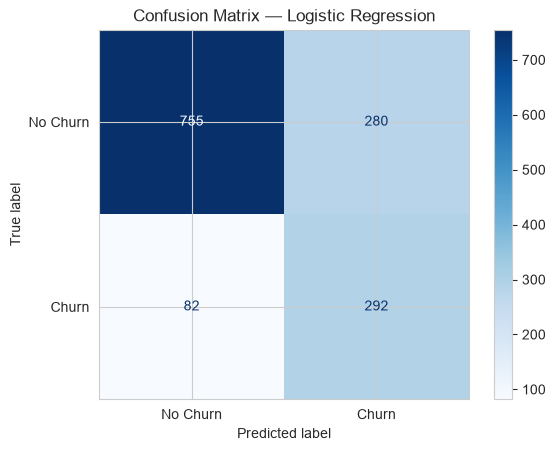

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409

ROC-AUC: 0.8333


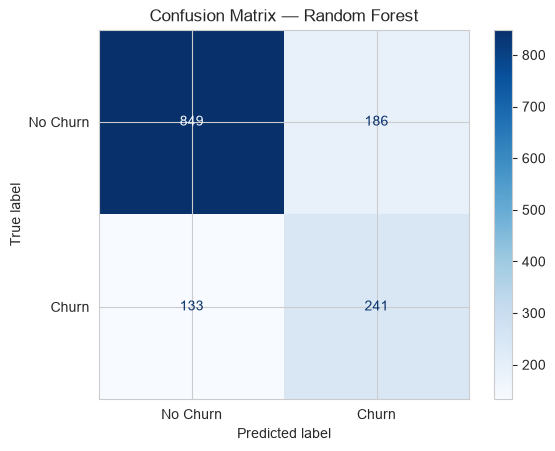

In [9]:

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(pipeline, X_test, y_test, name):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

evaluate_model(log_reg_pipeline, X_test, y_test, "Logistic Regression")
evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")

## Serialize Model

In [10]:


import joblib

joblib.dump(log_reg_pipeline, "../models/churn_model.pkl")
print("Model saved to ../models/churn_model.pkl")

Model saved to ../models/churn_model.pkl


In [11]:
loaded_model = joblib.load("../models/churn_model.pkl")
sample = X_test.iloc[[0]]
print("Prediction:", loaded_model.predict(sample))
print("Probability:", loaded_model.predict_proba(sample))

Prediction: [0]
Probability: [[0.81369571 0.18630429]]


# To create the API schema

In [12]:
for col in categorical_cols:
    print(col, ":", df[col].unique().tolist())

Gender : ['Male', 'Female']
Senior Citizen : ['No', 'Yes']
Partner : ['No', 'Yes']
Dependents : ['No', 'Yes']
Phone Service : ['Yes', 'No']
Multiple Lines : ['No', 'Yes', 'No phone service']
Internet Service : ['DSL', 'Fiber optic', 'No']
Online Security : ['Yes', 'No', 'No internet service']
Online Backup : ['Yes', 'No', 'No internet service']
Device Protection : ['No', 'Yes', 'No internet service']
Tech Support : ['No', 'Yes', 'No internet service']
Streaming TV : ['No', 'Yes', 'No internet service']
Streaming Movies : ['No', 'Yes', 'No internet service']
Contract : ['Month-to-month', 'Two year', 'One year']
Paperless Billing : ['Yes', 'No']
Payment Method : ['Mailed check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)']
